In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Human TF promoter-level chec-seq binding ignal
sumprom_chec_glob = "sumproms/*.gz"

# Yeast TF promoter-level chec-seq signal (see manuscript for source)
native_tf_sumprom_path = "../Yeast_Native_TF_outfiles/results/sumproms/*.gz"

## Imports

In [3]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

## Data Loading

In [4]:
# Load human TF promoter signals
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

In [5]:
FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {"FOXK1_WT": FOXK1_WT, "GABPA_WT": GABPA_WT, "SOX10_WT": SOX10_WT, "HXD10_WT": HXD10_WT, "GATA1_WT": GATA1_WT, "BATF3_WT": BATF3_WT, "HEY1_WT": HEY1_WT, "NFAC4_WT": NFAC4_WT, "TF2LY_WT": TF2LY_WT, "PO3F2_WT": PO3F2_WT}

In [6]:
wt_tfs = {tf for fam in dbd_fam_dict.values() for tf in fam}
sumprom_all = sumprom_all[[c for c in sumprom_all.columns if (m := re.match(r'^([^_]+)_([0-9])', c)) and m.group(1) in wt_tfs]]

## Correlation Analysis

In [7]:
# Compute replicate correlations and between-TF correlations
df = sumprom_all.copy()
base = df.columns.str.rsplit('_', n=2).str[0]

max_corrs = []
for _, cols in df.columns.to_series().groupby(base):
    if len(cols) > 1:
        c = df[cols].corr()
        m = c.values.copy()
        np.fill_diagonal(m, np.nan)
        max_corrs.append(np.nanmax(m))

avg = df.groupby(base, axis=1).mean()
m = avg.corr().values
np.fill_diagonal(m, np.nan)
avg_vals = m[~np.isnan(m)]

/tmp/ipykernel_3610185/4115106040.py:13: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  avg = df.groupby(base, axis=1).mean()


## Plot 1: TF Correlation Distribution

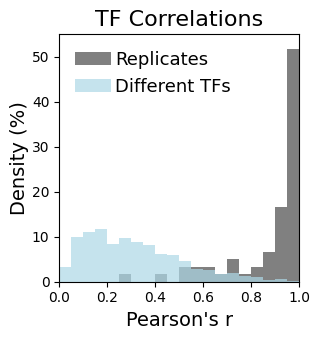

In [8]:
# --- Simple percentage histograms instead of smooth PDFs ---

bins = 20
hist_range = (0, 1)

fig, ax = plt.subplots(figsize=(3.3, 3.5))

# Weights to convert counts to percentages
w1 = np.ones_like(max_corrs) * 100.0 / len(max_corrs)
w2 = np.ones_like(avg_vals)  * 100.0 / len(avg_vals)

# Histogram for "Replicates of same TF"
ax.hist(
    max_corrs,
    bins=bins,
    range=hist_range,
    weights=w1,
    color="gray",
    alpha=1,
    label='Replicates'
)

# Histogram for "Between different TFs"
ax.hist(
    avg_vals,
    bins=bins,
    range=hist_range,
    weights=w2,
    color="lightblue",
    alpha=0.7,
    label='Different TFs'
)

ax.set_xlim(hist_range)
ax.set_ylim(0, 55)
ax.set_xlabel("Pearson's r", fontsize=14)
ax.set_ylabel('Density (%)', fontsize=14, labelpad=2)
ax.set_title('TF Correlations', fontsize=16)
ax.legend(loc="upper left", frameon=False, fontsize=13, handletextpad=0.2)

plt.tight_layout()
plt.show()


## Data Processing for Binding Strength

In [9]:
# Filter reproducible samples
corr_cutoff = 0.895

def filter_reproducible(sumprom_all: pd.DataFrame, cutoff):
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]
    
    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)

In [10]:
# Average replicates and compute z-scores
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit('_', n=2).str[0]
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom_z = sumprom.apply(zscore)

In [11]:
# Load yeast TF datasets
native_tf_sumprom_files = glob.glob(native_tf_sumprom_path)
native_tf_sumprom = pd.concat([pd.read_parquet(x) for x in native_tf_sumprom_files], axis=1)
non_transcription_factors = ['Nfi1', 'Itc1', 'Gal11', 'Nhp6A', 'Spt20', 'Nhp6B','Abf2', 'Tog1', 'Siz1', 'Cyc8', "Mss11"]
native_tf_sumprom = native_tf_sumprom.drop(columns=non_transcription_factors)
native_tf_sumprom_z = native_tf_sumprom.apply(zscore)

In [12]:
# Compute binding strength distributions

z_cutoff = 3

summed  = (sumprom * (sumprom_z > z_cutoff)).sum()
logged  = np.log2(summed + 1)

summed1 = (native_tf_sumprom * (native_tf_sumprom_z > z_cutoff)).sum()
logged1 = np.log2(summed1 + 1)

combined_min = min(logged.min(),  logged1.min())
combined_max = max(logged.max(),  logged1.max())
shared_range = (combined_min, combined_max)

bins = 19

counts0, edges = np.histogram(logged,  bins=bins, range=shared_range)
counts1, _     = np.histogram(logged1, bins=bins, range=shared_range)

h0 = counts0 * 100.0 / len(logged)
h1 = counts1 * 100.0 / len(logged1)

bin_widths = np.diff(edges)
bin_lefts  = edges[:-1]


## Plot 2: Binding Strength Distribution

/tmp/ipykernel_3610185/3882455369.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


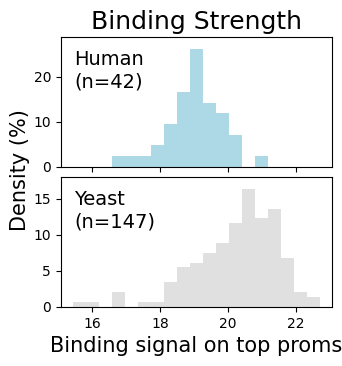

In [13]:
fig = plt.figure(figsize=(3.5, 3.5))
gs = fig.add_gridspec(2, 1, hspace=0.08)  # small vertical space

ax_top = fig.add_subplot(gs[0])
ax_mid = fig.add_subplot(gs[1], sharex=ax_top)

# ---- histograms ----
ax_top.bar(bin_lefts, h0, width=bin_widths, color="lightblue")
ax_mid.bar(bin_lefts, h1, width=bin_widths, color="lightgrey", alpha=0.7)

# ---- independent y-limits ----
ax_top.set_ylim(0, h0.max() * 1.1)
ax_mid.set_ylim(0, h1.max() * 1.1)

# ---- remove x-ticks only on top ----
ax_top.tick_params(labelbottom=False)

# ---- dataset labels inside each subplot ----
ax_top.text(
    0.05, 0.9, f"Human\n(n={len(summed)})",
    transform=ax_top.transAxes, ha="left", va="top", fontsize=14
)

ax_mid.text(
    0.05, 0.9, f"Yeast\n(n={len(summed1)})",
    transform=ax_mid.transAxes, ha="left", va="top", fontsize=14
)

# ---- shared axis labels ----
fig.supylabel("Density (%)", fontsize=15, x=-0.02)
ax_mid.set_xlabel("Binding signal on top proms", fontsize=15)

# ---- title ----
ax_top.set_title("Binding Strength", fontsize=18)

plt.tight_layout()
plt.show()
